# Environment

In [1]:
library(dplyr)
library(DBI)
library(RSQLite)
library(sf)
library(spdep)
library(sp)
library(tidyverse)
library(grf)
library(spatialRF)
library(arrow)


Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union


Warning message:
"package 'RSQLite' was built under R version 4.5.2"
Linking to GEOS 3.13.1, GDAL 3.11.0, PROJ 9.6.0; sf_use_s2() is TRUE

Loading required package: spData

To access larger datasets in this package, install the spDataLarge
package with: `install.packages('spDataLarge',
repos='https://nowosad.github.io/drat/', type='source')`

Warning message:
"package 'tidyverse' was built under R version 4.5.2"
Warning message:
"package 'readr' was built under R version 4.5.2"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.1     ✔ readr     2.1.6
✔ ggplot2   4.0.0     ✔ stringr   1.5.2
✔ lubridate 1.9.4     ✔ tibble    3.3.0
✔ purrr     1.1.0     ✔ tidyr     1.3.1
── Conflicts ────────────────────────────────────────── tidyverse_conflicts

# Loading data

In [2]:
repo_path <- dirname(file.path(getwd()))

In [3]:
con <- dbConnect(RSQLite::SQLite(),
                 paste0(repo_path,"/00_Data/lodz_regeneration_bpd.sqlite"))
block_panel <- dbReadTable(con, "panel_data")
#treatment <- dbReadTable(con, "staggered_treatment_encoded")
panel_data_narrowed_scope <- dbReadTable(con, "panel_data_narrowed_scope")
panel_data_enterpreneurs <- dbReadTable(con, "panel_data_enterpreneurs")

geom_df <- dbReadTable(con, "urban_blocks")
geom_sf <- st_as_sfc(geom_df$GEOMETRY, EWKB = TRUE) 
geom_sf <- st_sf(
  block_id = geom_df$block_id,
  geometry = geom_sf
)
st_crs(geom_sf) <- 2177

dbDisconnect(con)

In [5]:
block_panel$year <- as.POSIXct(block_panel$year)

In [6]:
names(block_panel)

[1] "year"                           "block_id"                      
 [3] "block_area"                     "train_test_split"              
 [5] "treated"                        "placebo"                       
 [7] "treat_stagg_group"              "placebo_stagg_group"           
 [9] "SCB_coun"                       "SCB_area_rat"                  
[11] "AOut_coun"                      "AOut_area_rat"                 
[13] "School_coun"                    "School_area_rat"               
[15] "KinderGard_coun"                "KinderGard_area_rat"           
[17] "PlayGrnd_coun"                  "PlayGrnd_area_rat"             
[19] "Build_Footprnt"                 "Build_Floor_Area_Rat"          
[21] "Abandoned_Build_Floor_Area_Rat" "Car_Park_Area"                 
[23] "Car_Park_Area_ratio"            "Scrubs_area"                   
[25] "Scrubs_area_ratio"              "Build_Perm_coun"               
[27] "Build_Perm_area_ratio"

In [7]:
blocks_2025 <- block_panel %>%
  filter(year(year) == 2025)
blocks_2019 <- block_panel %>%
  filter(year(year) == 2019)

In [8]:
blocks_2019$SCB_coun_diff <- blocks_2025$SCB_coun - blocks_2019$SCB_coun
blocks_2019$Build_Perm_coun_diff <- blocks_2025$Build_Perm_coun - blocks_2019$Build_Perm_coun

In [9]:
geom_sf_ent <- geom_sf[geom_sf$block_id %in% panel_data_enterpreneurs$block_id, ]
geom_sf_app <- geom_sf[geom_sf$block_id %in% panel_data_narrowed_scope$block_id, ]

In [10]:
ent_2025 <- panel_data_enterpreneurs %>%
  filter(year(year) == 2025)
ent_2015 <- panel_data_enterpreneurs %>%
  filter(year(year) == 2015)

app_2025 <- panel_data_narrowed_scope %>%
  filter(year(year) == 2025)
app_2019 <- panel_data_narrowed_scope %>%
  filter(year(year) == 2019)

In [11]:
app_2019$app_prices_diff <- app_2025$Appartment_prices_avrg - app_2019$Appartment_prices_avrg
ent_2015$Build_with_resid_entrpr_diff <- ent_2025$Build_with_resid_entrpr - ent_2015$Build_with_resid_entrpr

# W matrix

## SCB building permits

In [12]:
cont_mn <- poly2nb(geom_sf, queen = T)
W1_list_mn <- nb2listw(cont_mn, style = "W")

In [13]:
centroids <- sf::st_centroid(geom_sf)

distance_matrix <- units::drop_units(
  as.matrix(sf::st_distance(centroids))
)

Warning message:
"st_centroid assumes attributes are constant over geometries"


In [14]:
distance_matrix 

,1,2,3,4,5,6,7,8,9,10,⋯,274,275,276,277,278,279,280,281,282,283
1,0.0000,117.3406,1444.3593,1771.0154,2075.6480,2026.1160,1780.2498,1628.4923,1541.1080,1698.6711,⋯,2687.191,2481.308,3556.693,3246.212,3093.339,3062.283,2824.0757,2759.990,2351.0171,2342.387
2,117.3406,0.0000,1533.0390,1851.5045,2148.3498,2093.1405,1853.0426,1705.5666,1611.7525,1765.1609,⋯,2604.278,2396.908,3599.932,3289.897,3128.614,3107.863,2875.8884,2794.018,2371.4890,2345.348
3,1444.3593,1533.0390,0.0000,362.6500,707.2151,717.5875,449.9557,283.6706,333.8605,474.3720,⋯,3126.174,2968.090,2359.866,2060.547,2001.437,1869.596,1588.0245,1713.047,1526.9362,1734.449
4,1771.0154,1851.5045,362.6500,0.0000,346.2348,378.4011,157.2866,159.5945,299.2981,282.8700,⋯,3160.900,3020.399,2010.222,1715.564,1677.639,1525.655,1239.3783,1409.297,1305.2993,1565.563
5,2075.6480,2148.3498,707.2151,346.2348,0.0000,136.0966,295.4407,454.2699,537.2631,400.4614,⋯,3185.260,3063.160,1668.947,1378.576,1361.592,1190.267,900.8086,1119.426,1117.5901,1424.981
6,2026.1160,2093.1405,717.5875,378.4011,136.0966,0.0000,270.3619,441.2645,488.2148,327.9862,⋯,3051.348,2930.842,1642.335,1343.367,1299.257,1152.621,870.5380,1035.954,993.4584,1293.881
7,1780.2498,1853.0426,449.9557,157.2866,295.4407,270.3619,0.0000,170.9035,243.4726,145.6086,⋯,3029.688,2893.970,1911.596,1611.058,1554.332,1420.004,1140.0692,1274.250,1149.6311,1408.370
8,1628.4923,1705.5666,283.6706,159.5945,454.2699,441.2645,170.9035,0.0000,145.8995,204.4747,⋯,3027.672,2882.803,2081.894,1780.605,1717.788,1589.457,1310.5799,1430.502,1267.8251,1500.909
9,1541.1080,1611.7525,333.8605,299.2981,537.2631,488.2148,243.4726,145.8995,0.0000,171.4426,⋯,2884.631,2738.433,2100.961,1794.861,1708.761,1603.943,1335.0438,1406.599,1194.1012,1402.933
10,1698.6711,1765.1609,474.3720,282.8700,400.4614,327.9862,145.6086,204.4747,171.4426,0.0000,⋯,2885.443,2748.837,1929.534,1623.569,1541.021,1432.608,1163.7949,1243.384,1063.3998,1299.947


## App prices

In [15]:
cont_mn1 <- poly2nb(geom_sf_app, queen = T)
W1_list_mn1 <- nb2listw(cont_mn1, style = "W")

In [16]:
centroids1 <- sf::st_centroid(geom_sf_app)

distance_matrix1 <- units::drop_units(
  as.matrix(sf::st_distance(centroids1))
)

Warning message:
"st_centroid assumes attributes are constant over geometries"


## Enterpreneurs

In [17]:
cont_mn2 <- poly2nb(geom_sf_ent, queen = T)
W1_list_mn2 <- nb2listw(cont_mn2, style = "W")

In [18]:
centroids2 <- sf::st_centroid(geom_sf_ent)

distance_matrix2 <- units::drop_units(
  as.matrix(sf::st_distance(centroids2))
)

Warning message:
"st_centroid assumes attributes are constant over geometries"


# Modeling

## Small catering businesses

The model residuals are spatially correlated, fitting a spatial model.

Using Moran's Eigenvector Maps as spatial predictors.

Ranking spatial predictors by their Moran's I.

Sequential selection of spatial predictors.

Details about the spatial predictors stored in model$spatial.



Model type
  - Fitted with:                     rf_spatial()
  - rf_spatial() method:             mem.moran.sequential
  - Response variable:               SCB_coun_diff

Random forest parameters
  - Type:                            Regression
  - Number of trees:                 500
  - Sample size:                     283
  - Number of predictors:            31
  - Mtry:                            5
  - Minimum node size:               5


Model performance 
  - R squared (oob):                  0.2150187
  - R squared (cor(obs, pred)^2):     0.9370908
  - Pseudo R squared (cor(obs, pred)):0.9680345
  - RMSE (oob):                       1.993329
  - RMSE:                             0.8731
  - Normalized RMSE:                  0.8731

Model residuals 
  - Stats: 
              ┌───────┬────────┬────────┬───────┬────────┬──────┐
              │ Min.  │ 1st Q. │ Median │ Mean  │ 3rd Q. │ Max. │
              ├───────┼────────┼────────┼───────┼────────┼──────┤
              │ -3.21 │  -

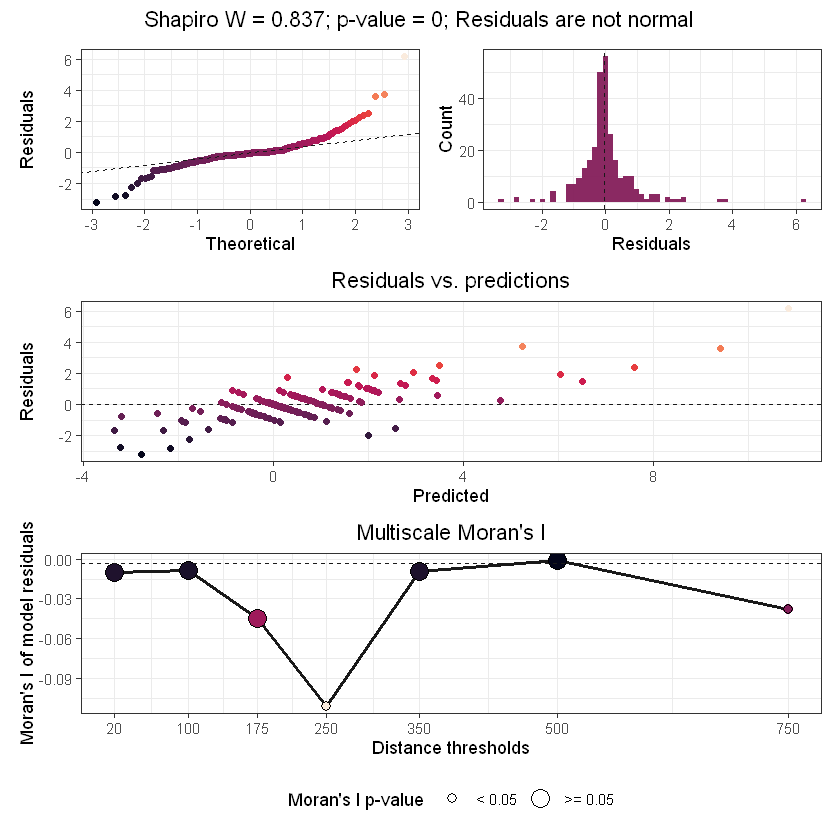

In [19]:
m_scb <- spatialRF::rf_spatial(
  data = blocks_2019,
  dependent.variable.name = "SCB_coun_diff",
  predictor.variable.names = c('Scrubs_area_ratio',  'Abandoned_Build_Floor_Area_Rat', "Build_Footprnt", 'Car_Park_Area_ratio'),
  distance.matrix = distance_matrix,
  distance.thresholds = c(20,100, 175, 250, 350, 500, 750)
  )

In [20]:
spatial.predictors_scb <- spatialRF::get_spatial_predictors(m_scb)

In [54]:
names(spatial.predictors_scb)

[1] "spatial_predictor_500_1"  "spatial_predictor_500_2" 
 [3] "spatial_predictor_500_3"  "spatial_predictor_500_4" 
 [5] "spatial_predictor_20_6"   "spatial_predictor_500_7" 
 [7] "spatial_predictor_20_7"   "spatial_predictor_500_12"
 [9] "spatial_predictor_350_3"  "spatial_predictor_500_8" 
[11] "spatial_predictor_20_9"   "spatial_predictor_20_10" 
[13] "spatial_predictor_500_11" "spatial_predictor_20_11" 
[15] "spatial_predictor_500_9"  "spatial_predictor_500_5" 
[17] "spatial_predictor_350_15" "spatial_predictor_500_10"
[19] "spatial_predictor_20_13"  "spatial_predictor_500_16"
[21] "spatial_predictor_500_6"  "spatial_predictor_20_16" 
[23] "spatial_predictor_350_6"  "spatial_predictor_500_15"
[25] "spatial_predictor_500_14" "spatial_predictor_500_17"
[27] "spatial_predictor_20_19"

## Building permits

In [21]:
m_bpd <- spatialRF::rf_spatial(
  data = blocks_2019,
  dependent.variable.name = "Build_Perm_coun_diff",
  predictor.variable.names = c('Scrubs_area_ratio',  'Abandoned_Build_Floor_Area_Rat', "Build_Footprnt", 'Car_Park_Area_ratio'),
  distance.matrix = distance_matrix,
  distance.thresholds = c(20,100, 175, 250, 350, 500, 750)
  )

The model residuals are not spatially correlated, there is no need to fit a spatial model

Using Moran's Eigenvector Maps as spatial predictors.

Ranking spatial predictors by their Moran's I.

No spatial predictors remain after filtering. Returning non-spatial model.



## Appartment prices

The model residuals are spatially correlated, fitting a spatial model.

Using Moran's Eigenvector Maps as spatial predictors.

Ranking spatial predictors by their Moran's I.

Sequential selection of spatial predictors.

Details about the spatial predictors stored in model$spatial.



Model type
  - Fitted with:                     rf_spatial()
  - rf_spatial() method:             mem.moran.sequential
  - Response variable:               app_prices_diff

Random forest parameters
  - Type:                            Regression
  - Number of trees:                 500
  - Sample size:                     127
  - Number of predictors:            12
  - Mtry:                            3
  - Minimum node size:               5


Model performance 
  - R squared (oob):                  -0.02782125
  - R squared (cor(obs, pred)^2):     0.9165472
  - Pseudo R squared (cor(obs, pred)):0.9573647
  - RMSE (oob):                       1813.02
  - RMSE:                             820.79
  - Normalized RMSE:                  0.3980896

Model residuals 
  - Stats: 
           ┌──────────┬─────────┬────────┬───────┬────────┬─────────┐
           │ Min.     │ 1st Q.  │ Median │ Mean  │ 3rd Q. │ Max.    │
           ├──────────┼─────────┼────────┼───────┼────────┼─────────┤
        

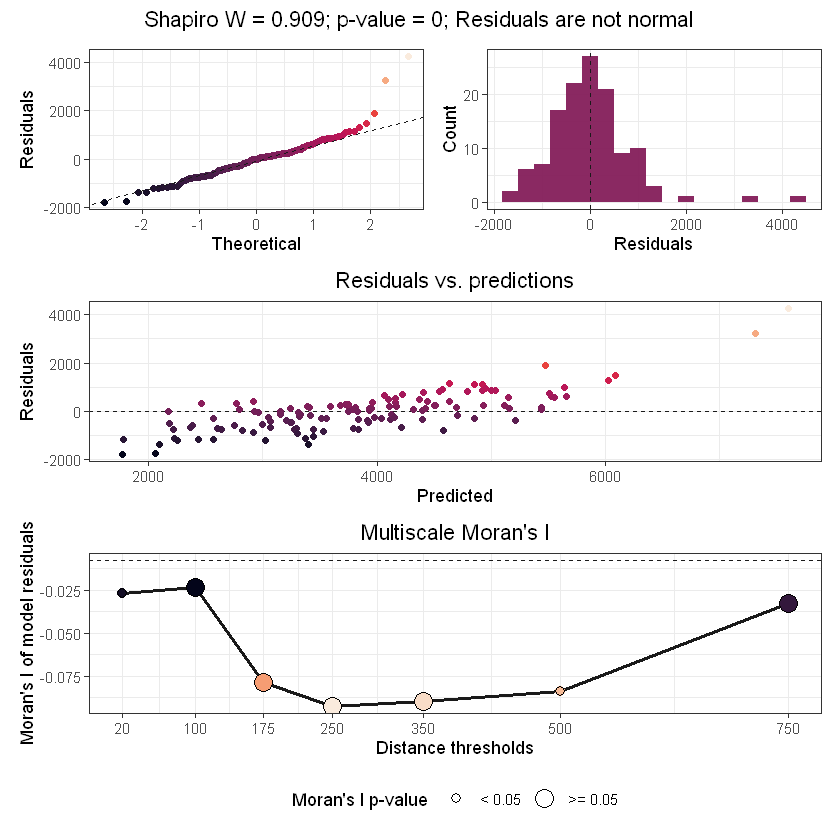

In [22]:
m_app <- spatialRF::rf_spatial(
  data = app_2019,
  dependent.variable.name = "app_prices_diff",
  predictor.variable.names = c('Scrubs_area_ratio',  'Abandoned_Build_Floor_Area_Rat', "Build_Footprnt", 'Car_Park_Area_ratio'),
  distance.matrix = distance_matrix1,
  distance.thresholds = c(20,100, 175, 250, 350, 500, 750)
  )

In [23]:
spatial.predictors_app <- spatialRF::get_spatial_predictors(m_app)

In [59]:
names(spatial.predictors_app)

[1] "spatial_predictor_100_3"  "spatial_predictor_250_2" 
[3] "spatial_predictor_250_10" "spatial_predictor_100_5" 
[5] "spatial_predictor_100_6"  "spatial_predictor_250_9" 
[7] "spatial_predictor_250_5"  "spatial_predictor_100_7"

## Enterpreneurs

The model residuals are spatially correlated, fitting a spatial model.

Using Moran's Eigenvector Maps as spatial predictors.

Ranking spatial predictors by their Moran's I.

Sequential selection of spatial predictors.

Details about the spatial predictors stored in model$spatial.



Model type
  - Fitted with:                     rf_spatial()
  - rf_spatial() method:             mem.moran.sequential
  - Response variable:               Build_with_resid_entrpr_diff

Random forest parameters
  - Type:                            Regression
  - Number of trees:                 500
  - Sample size:                     142
  - Number of predictors:            47
  - Mtry:                            6
  - Minimum node size:               5


Model performance 
  - R squared (oob):                  0.2199081
  - R squared (cor(obs, pred)^2):     0.9362038
  - Pseudo R squared (cor(obs, pred)):0.9675762
  - RMSE (oob):                       5.060911
  - RMSE:                             2.1481
  - Normalized RMSE:                  0.2771742

Model residuals 
  - Stats: 
              ┌───────┬────────┬────────┬───────┬────────┬──────┐
              │ Min.  │ 1st Q. │ Median │ Mean  │ 3rd Q. │ Max. │
              ├───────┼────────┼────────┼───────┼────────┼──────┤
        

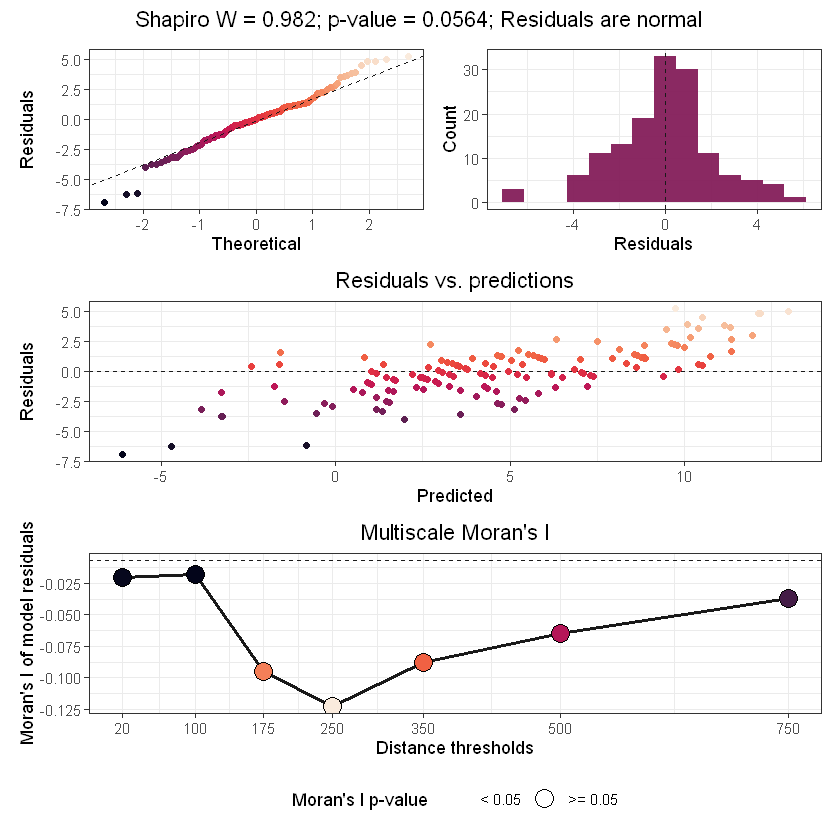

In [24]:
m_ent <- spatialRF::rf_spatial(
  data = ent_2015,
  dependent.variable.name = "Build_with_resid_entrpr_diff",
  predictor.variable.names = c('Scrubs_area_ratio',  'Abandoned_Build_Floor_Area_Rat', "Build_Footprnt", 'Car_Park_Area_ratio'),
  distance.matrix = distance_matrix2,
  distance.thresholds = c(20,100, 175, 250, 350, 500, 750)
  )

In [25]:
spatial.predictors_ent <- spatialRF::get_spatial_predictors(m_ent)

In [60]:
names(spatial.predictors_ent)

[1] "spatial_predictor_500_1"  "spatial_predictor_500_3" 
 [3] "spatial_predictor_250_14" "spatial_predictor_250_4" 
 [5] "spatial_predictor_350_6"  "spatial_predictor_350_8" 
 [7] "spatial_predictor_100_6"  "spatial_predictor_350_7" 
 [9] "spatial_predictor_250_2"  "spatial_predictor_175_24"
[11] "spatial_predictor_100_7"  "spatial_predictor_250_3" 
[13] "spatial_predictor_250_13" "spatial_predictor_100_9" 
[15] "spatial_predictor_250_8"  "spatial_predictor_175_27"
[17] "spatial_predictor_100_1"  "spatial_predictor_175_13"
[19] "spatial_predictor_500_7"  "spatial_predictor_175_4" 
[21] "spatial_predictor_175_5"  "spatial_predictor_250_9" 
[23] "spatial_predictor_250_5"  "spatial_predictor_175_29"
[25] "spatial_predictor_250_10" "spatial_predictor_250_20"
[27] "spatial_predictor_250_11" "spatial_predictor_350_11"
[29] "spatial_predictor_250_18" "spatial_predictor_750_9" 
[31] "spatial_predictor_350_13" "spatial_predictor_500_12"
[33] "spatial_predictor_100_13" "spatial_predictor_175_10"
[35] "spatial_predictor_175_9"  "spatial_predictor_250_7" 
[37] "spatial_predictor_100_14" "spatial_predictor_175_20"
[39] "spatial_predictor_350_19" "spatial_predictor_250_21"
[41] "spatial_predictor_250_16" "spatial_predictor_100_15"
[43] "spatial_predictor_500_11"

In [62]:
spatial.predictors_ent['spatial_predictor_500_1']

,spatial_predictor_500_1
,<dbl>
1,0.085950555
2,0.112280993
3,0.128917027
4,0.105741590
5,0.097919342
6,0.094120964
7,0.114102610
8,-0.015073194
9,-0.019510024


# Saving data

In [ ]:
#write_parquet(spatial.predictors_scb, "C:/Users/andre/Desktop/IDS/02_VS_code/02_building_permits_and_regeneration/00_Data/spatial_predictors_SCB_coun.parquet")
#write_parquet(spatial.predictors_ent, "C:/Users/andre/Desktop/IDS/02_VS_code/02_building_permits_and_regeneration/00_Data/spatial_predictors_enterpr.parquet")
#write_parquet(spatial.predictors_app, "C:/Users/andre/Desktop/IDS/02_VS_code/02_building_permits_and_regeneration/00_Data/spatial_predictors_app.parquet")